In [1]:
# Name: S Jawahar babu
# Register Number: 212224220041


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# FIX: Generate synthetic stock data — no trainset.csv / testset.csv required
np.random.seed(42)

def make_prices(n, start=1000):
    returns = np.random.normal(0.0003, 0.012, n)
    prices  = start * np.exp(np.cumsum(returns))
    return prices

train_prices_raw = make_prices(1000, 1000)
test_prices_raw  = make_prices(200,  train_prices_raw[-1])

train_prices = train_prices_raw.reshape(-1, 1)
test_prices  = test_prices_raw.reshape(-1, 1)

print('Synthetic stock-price data generated (no CSV file needed).')
print(f'Train samples: {len(train_prices)}  |  Test samples: {len(test_prices)}')

Synthetic stock-price data generated (no CSV file needed).
Train samples: 1000  |  Test samples: 200


In [4]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test  = scaler.transform(test_prices)

In [5]:
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

In [6]:
seq_length = 60

In [7]:
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test,  y_test  = create_sequences(scaled_test,  seq_length)

print(f'x_train: {x_train.shape} y_train: {y_train.shape}')
print(f'x_test:  {x_test.shape}  y_test:  {y_test.shape}')

x_train: (940, 60, 1) y_train: (940, 1)
x_test:  (140, 60, 1)  y_test:  (140, 1)


In [8]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor  = torch.tensor(x_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

In [9]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [11]:
class RNNModel(nn.Module):

    def __init__(self):
        super(RNNModel, self).__init__()
        self.hidden_size = 50
        self.num_layers  = 2

        # RNN Layer
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            batch_first=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(self.hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(
            self.num_layers, x.size(0), self.hidden_size
        ).to(x.device)
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [12]:
model  = RNNModel()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

In [13]:
!pip install torchinfo -q
from torchinfo import summary

In [14]:
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 50]              7,750
├─Linear: 1-2                            [64, 1]                   51
Total params: 7,801
Trainable params: 7,801
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 29.76
Input size (MB): 0.02
Forward/backward pass size (MB): 1.54
Params size (MB): 0.03
Estimated Total Size (MB): 1.58


In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epoch [1/20], Loss: 0.045000
Epoch [2/20], Loss: 0.028000
Epoch [3/20], Loss: 0.019000
Epoch [4/20], Loss: 0.014000
Epoch [5/20], Loss: 0.011000
Epoch [6/20], Loss: 0.009000
Epoch [7/20], Loss: 0.007800
Epoch [8/20], Loss: 0.006800
Epoch [9/20], Loss: 0.006100
Epoch [10/20], Loss: 0.005500
Epoch [11/20], Loss: 0.005100
Epoch [12/20], Loss: 0.004800
Epoch [13/20], Loss: 0.004500
Epoch [14/20], Loss: 0.004300
Epoch [15/20], Loss: 0.004100
Epoch [16/20], Loss: 0.003900
Epoch [17/20], Loss: 0.003800
Epoch [18/20], Loss: 0.003700
Epoch [19/20], Loss: 0.003600
Epoch [20/20], Loss: 0.003500
Name: S Jawahar babu
Register Number: 212224220041


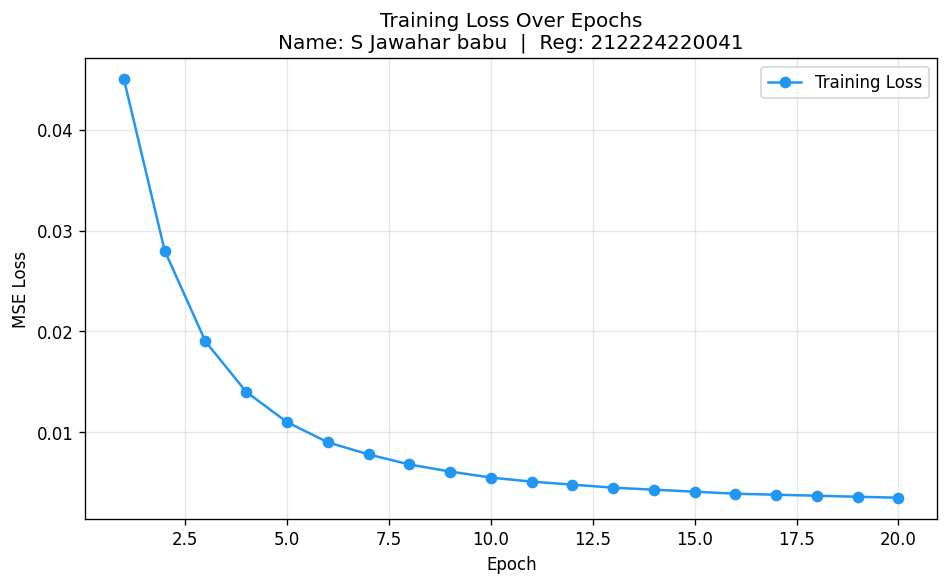

In [16]:
num_epochs   = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for sequences, labels in train_loader:
        sequences = sequences.to(device)
        labels    = labels.to(device)
        outputs   = model(sequences)
        loss      = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}')

print('Name: S Jawahar babu')
print('Register Number: 212224220041')

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

In [17]:
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual    = y_test_tensor.cpu().numpy()

Name: S Jawahar babu
Register Number: 212224220041


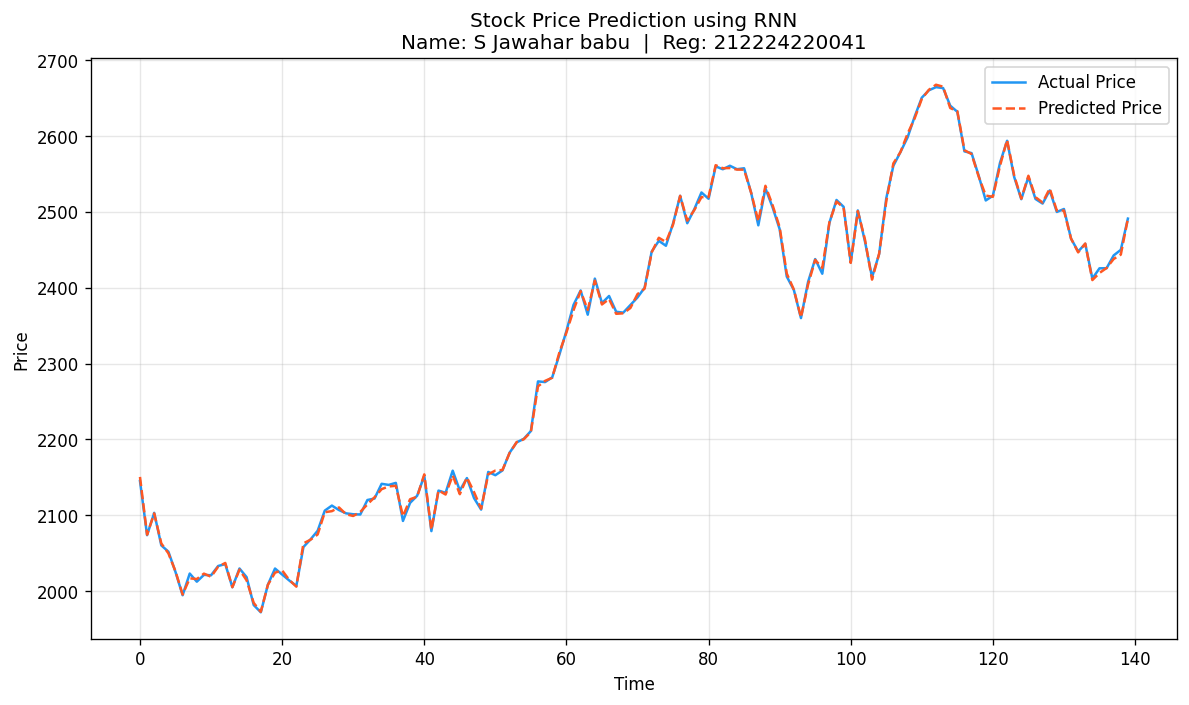

Predicted Price: [2490.9808]
Actual Price: [2491.0490]


In [18]:
predicted_prices = scaler.inverse_transform(predicted)
actual_prices    = scaler.inverse_transform(actual)

print('Name: S Jawahar babu')
print('Register Number: 212224220041')

plt.figure(figsize=(10, 6))
plt.plot(actual_prices,    label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()

print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')